In [42]:

# BENÖTIGTE BIBLIOTHEKEN IMPORTIEREN

# pandas -> wichtigste Bibliothek für Datenanalyse und Tabellen (DataFrames)
import pandas as pd

# json -> zum Einlesen der Eurostat JSON Dateien
import json

# matplotlib -> Bibliothek für statische Diagramme
import matplotlib.pyplot as plt

# seaborn -> Erweiterung von matplotlib für schönere statistische Visualisierungen
import seaborn as sns

# plotly -> Bibliothek für interaktive Grafiken (für Data Science Projekte sehr beliebt)
import plotly.express as px

In [43]:

# FUNKTION ZUM KONVERTIEREN DER EUROSTAT JSON DATEIEN

# Diese Funktion liest eine Eurostat JSON Datei ein und
# wandelt sie in ein pandas DataFrame um.
# Das Ergebnis enthält:
# - datum  -> Zeitstempel
# - preis  -> CPI / PPI Wert

# 1. FUNKTION (Muss in jeder neuen Datei stehen, damit sie funktioniert)
def eurostat_json_to_df(file_path):
    
    # JSON Datei öffnen und als Python Dictionary laden
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    # Eurostat speichert Zeitinformationen in einer verschachtelten Struktur.
    # "index" enthält die Position jedes Zeitpunkts.
    time_index = data['dimension']['time']['category']['index'] 
    
    # "label" enthält die eigentlichen Zeitwerte (z.B. 2020M01)
    time_labels = data['dimension']['time']['category']['label'] 
    
    # "value" enthält die numerischen Werte (z.B. Preisindex)
    values = data['value'] 
    
    # Hier speichern wir später alle Datenzeilen
    rows = []
    
    # Wir gehen jede Zeitperiode durch
    for label_key, position in time_index.items():
        
        # Die Position wird als String benötigt,
        # weil sie im JSON als String gespeichert ist
        pos_str = str(position)
        
        # Prüfen ob für diese Zeitperiode ein Wert existiert
        if pos_str in values:
            
            # Falls ja -> neue Zeile erstellen
            rows.append({
                'datum_raw': time_labels[label_key],  # Originaldatum aus Eurostat (z.B. 2020M01)
                'preis': values[pos_str]              # Preiswert / Indexwert
            })
    
    # Liste der Zeilen in ein DataFrame umwandeln
    df = pd.DataFrame(rows)
    
    # Datum in ein echtes Datumsformat umwandeln
    # Beispiel:
    # 2020M01 -> 2020-01
    df['datum'] = pd.to_datetime(df['datum_raw'].str.replace('M', '-'), format='%Y-%m')
    
    # Nur relevante Spalten zurückgeben und nach Datum sortieren
    return df[['datum', 'preis']].sort_values('datum')

In [44]:

# DATEN LADEN

# Wir laden zwei Datensätze aus Eurostat:
# 1. Butter Preisindex
# 2. Margarine Preisindex

# 2. DATEN LADEN (Für Butter und Margarine)
# Wir nutzen die Dateien, die du hochgeladen hast

# Butter CPI laden und Spalte umbenennen
# CPI = Consumer Price Index (Verbraucherpreisindex)
df_butter = eurostat_json_to_df('eurostat_butter_cpi.json').rename(columns={'preis': 'butter_cpi'})

# Margarine CPI laden und ebenfalls Spalte umbenennen
df_margarine = eurostat_json_to_df('eurostat_cpi_dairy.json').rename(columns={'preis': 'margarine_cpi'})

In [45]:

# DATENSÄTZE ZUSAMMENFÜHREN

# Beide Datensätze enthalten eine Datumsspalte.
# Über diese verbinden wir die Daten.

# 3. ZUSAMMENFÜHREN & ZEITRAUM FILTERN

# Merge verbindet beide Datensätze über das Datum
df_vergleich = pd.merge(df_butter, df_margarine, on='datum', how='inner')

# Wir betrachten nur Daten ab Januar 2020
# (Projektzeitraum der Analyse)
df_vergleich = df_vergleich[df_vergleich['datum'] >= '2020-01-01'].reset_index(drop=True)

In [46]:
# PREISE NORMIEREN
# Normierung bedeutet:
# Wir setzen den Preis im Startmonat (Jan 2020) auf 100.
# Dadurch können wir sehen, wie stark Preise relativ gestiegen sind.

# 4. NORMIERUNG (Januar 2020 = 100)

# Butter Preisindex relativ zum Startwert
df_vergleich['butter_norm'] = (df_vergleich['butter_cpi'] / df_vergleich['butter_cpi'].iloc[0]) * 100

# Margarine Preisindex relativ zum Startwert
df_vergleich['margarine_norm'] = (df_vergleich['margarine_cpi'] / df_vergleich['margarine_cpi'].iloc[0]) * 100

In [47]:

# AUTOMATISCHE AUSWERTUNG DER FORSCHUNGSFRAGE

# Wir untersuchen:
# Welches Produkt während der Inflation stärker gestiegen ist.

# 5. AUTOMATISCHE ANTWORT GENERIEREN

# Höchster Wert der normierten Preisreihe
max_butter = df_vergleich['butter_norm'].max()
max_margarine = df_vergleich['margarine_norm'].max()

print("-" * 50)
print(f"ERGEBNIS ANALYSE FRAGE 2 (ab 2020)")
print("-" * 50)

# Prozentuale Preissteigerung berechnen
print(f"Maximaler Preisanstieg Butter:    {max_butter - 100:.2f}%")
print(f"Maximaler Preisanstieg Margarine: {max_margarine - 100:.2f}%")

print("-" * 50)
print("ANTWORT:")

# Interpretation
if max_butter > max_margarine:
    print("Butter verzeichnete während der Inflation einen deutlich höheren Preisausschlag als Margarine.")
    print("Dies deutet darauf hin, dass tierische Fette stärker von den Kostensteigerungen betroffen waren.")
else:
    print("Margarine stieg preislich ähnlich stark oder stärker als Butter.")

print("-" * 50)

--------------------------------------------------
ERGEBNIS ANALYSE FRAGE 2 (ab 2020)
--------------------------------------------------
Maximaler Preisanstieg Butter:    60.73%
Maximaler Preisanstieg Margarine: 48.24%
--------------------------------------------------
ANTWORT:
Butter verzeichnete während der Inflation einen deutlich höheren Preisausschlag als Margarine.
Dies deutet darauf hin, dass tierische Fette stärker von den Kostensteigerungen betroffen waren.
--------------------------------------------------


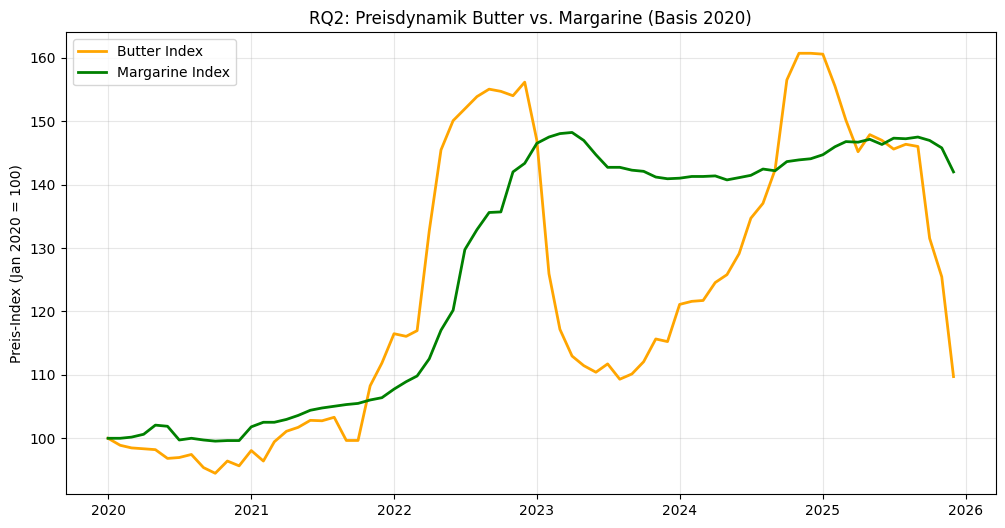

In [48]:

# STATISCHE VISUALISIERUNG

# Hier erstellen wir ein klassisches Liniendiagramm
# mit matplotlib.

# 6. VISUALISIERUNG (Statisch)

plt.figure(figsize=(12, 6))

# Butter Preisentwicklung
plt.plot(df_vergleich['datum'], df_vergleich['butter_norm'], label='Butter Index', color='orange', lw=2)

# Margarine Preisentwicklung
plt.plot(df_vergleich['datum'], df_vergleich['margarine_norm'], label='Margarine Index', color='green', lw=2)

# Diagrammtitel
plt.title('RQ2: Preisdynamik Butter vs. Margarine (Basis 2020)')

# Y-Achse
plt.ylabel('Preis-Index (Jan 2020 = 100)')

# Legende anzeigen
plt.legend()

# Gitternetz zur besseren Lesbarkeit
plt.grid(True, alpha=0.3)

# Grafik anzeigen
plt.show()

In [49]:

# VISUALISIERUNG

# Plotly erstellt interaktive Diagramme.
# Man kann zoomen, Datenpunkte ansehen und Zeiträume auswählen.

# 7. VISUALISIERUNG (Interaktiv - Pflicht für das Projekt)

fig = px.line(df_vergleich, x='datum', y=['butter_norm', 'margarine_norm'], 
              title='Interaktiver Vergleich: Wer wurde während der Inflation teurer?',
              labels={'value': 'Index-Wert', 'datum': 'Zeitpunkt'})

# Interaktive Grafik anzeigen
fig.show()